## Dashen Bank Review Analysis

Import Required Libraries

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Defining Variables

In [3]:
App_Id = "com.dashen.dashensuperapp"
bank = 'Dashen Bank'
source = 'Google Play Store'
print(f" Scraping Review for Bank: {bank} with App ID: {App_Id} from Source: {source}")


 Scraping Review for Bank: Dashen Bank with App ID: com.dashen.dashensuperapp from Source: Google Play Store


## Mobile App Review Data Scraping from Google Play Store

In [4]:
# Get meta data for the app
scrape_metadata(App_Id, bank)

App Info for Dashen Bank
App Title   : Dashen Bank
Current Score: 4.219512
Total Ratings: 5,718
Total Reviews: 1,030
Installs     : 1,000,000+


{'title': 'Dashen Bank',
 'description': 'Why choose Dashen Bank Super App?\r\n• Secure & Reliable: Built with robust security to protect your financial transactions.\r\n• Convenient: Manage your accounts, pay bills, and access essential services in one place.\r\n• User-Friendly: Simplified design for seamless navigation and usage.',
 'descriptionHTML': 'Why choose Dashen Bank Super App?<br>• Secure &amp; Reliable: Built with robust security to protect your financial transactions.<br>• Convenient: Manage your accounts, pay bills, and access essential services in one place.<br>• User-Friendly: Simplified design for seamless navigation and usage.',
 'summary': 'Bank smarter, pay bills easily, and access essential lifestyle services',
 'installs': '1,000,000+',
 'minInstalls': 1000000,
 'realInstalls': 1542211,
 'score': 4.219512,
 'ratings': 5718,
 'reviews': 1030,
 'histogram': [647, 259, 328, 438, 4044],
 'price': 0,
 'free': True,
 'currency': 'USD',
 'sale': False,
 'saleTime': None,

In [5]:
#scrape 500 reviews for the app
df_reviews, continuation_token = scrape_reviews(App_Id, bank, count=500)
df_reviews = pd.DataFrame(df_reviews)

Collected 500 raw reviews for Dashen Bank app.


In [6]:
print(type(df_reviews))

<class 'pandas.DataFrame'>


In [7]:
print(df_reviews.head())
print(df_reviews.columns)

                               reviewId           userName  \
0  ff40f684-8fce-4cba-a810-832b5ea598c9        Yared Donis   
1  c5eb5e78-501c-41ef-ae30-1f762e7def48       Anuwar Zinab   
2  2c5fdb1c-0946-4fc1-b8cd-c3cc10c54165    Tekalign Galata   
3  0fc2de51-e53c-4eea-9db3-66bdb13121e0  gebreyohans hagos   
4  e12c0c30-3995-4ad2-b5d1-8c61b519ce76       Fitiwi Habtu   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a/ACg8oc...   
2  https://play-lh.googleusercontent.com/a-/ALV-U...   
3  https://play-lh.googleusercontent.com/a/ACg8oc...   
4  https://play-lh.googleusercontent.com/a/ACg8oc...   

                                             content  score  thumbsUpCount  \
0  Terrible app. It does not work. I can't use my...      1              0   
1  you can’t transfer to others banks and it is b...      1              0   
2                                            love me    

In [8]:
# Inspect what a single raw review looks like

print("Keys in a single review:")
print(list(df_reviews.iloc[0].keys()))

print("\nFirst raw review (sample):")
for key, value in df_reviews.iloc[0].items():
    print(f"  {key}: {value}")

Keys in a single review:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

First raw review (sample):
  reviewId: ff40f684-8fce-4cba-a810-832b5ea598c9
  userName: Yared Donis
  userImage: https://play-lh.googleusercontent.com/a-/ALV-UjXQKgY2ej5njEwOVWaESFI9Zs-ZZ6P1JK9M07Zw0fIpKBTbMPlF
  content: Terrible app. It does not work. I can't use my money for anything. Can't even use the mobile airtime top up. I don't recommend it. Use it at your own risk.
  score: 1
  thumbsUpCount: 0
  reviewCreatedVersion: nan
  at: 2026-05-19 03:29:32
  replyContent: nan
  repliedAt: NaT
  appVersion: nan


In [9]:
# Step 3: Extract only the columns we need
raw_data = []

for r in df_reviews.itertuples():
    raw_data.append({
        'review_id': r.reviewId,
        'review'   : r.content,
        'rating'   : r.score,
        'date'     : r.at,
        'bank'     : bank,
        'source'   : 'Google Play'
    })

# Build a DataFrame
df_raw = pd.DataFrame(raw_data)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 6)


,review_id,review,rating,date,bank,source
0,ff40f684-8fce-4cba-a810-832b5ea598c9,Terrible app. It does not work. I can't use my...,1,2026-05-19 03:29:32,Dashen Bank,Google Play
1,c5eb5e78-501c-41ef-ae30-1f762e7def48,you can’t transfer to others banks and it is b...,1,2026-05-18 13:07:31,Dashen Bank,Google Play
2,2c5fdb1c-0946-4fc1-b8cd-c3cc10c54165,love me,5,2026-05-18 07:41:12,Dashen Bank,Google Play
3,0fc2de51-e53c-4eea-9db3-66bdb13121e0,"It is a very cool application, but it requires...",4,2026-05-17 11:12:31,Dashen Bank,Google Play
4,e12c0c30-3995-4ad2-b5d1-8c61b519ce76,excellent,5,2026-05-17 09:55:52,Dashen Bank,Google Play


## Exploring the Raw Data

In [10]:
# Basic shape and types
print(f"Total reviews collected: {len(df_raw)}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Total reviews collected: 500

Column dtypes:
review_id               str
review                  str
rating                int64
date         datetime64[us]
bank                    str
source                  str
dtype: object


In [11]:
print("Rating Distribution:")
rating_counts = df_raw['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_counts.items():
    bar = '█' * (count // 4) 
    print(f"{rating} stars: {bar} ({count} reviews)")


Rating Distribution:
5 stars: █████████████████████████████████████████████████████████████████████████████████ (324 reviews)
4 stars: ████████ (33 reviews)
3 stars: ██████ (26 reviews)
2 stars: ████ (18 reviews)
1 stars: ████████████████████████ (99 reviews)


In [12]:
# What does the date column look like right now?
print("Sample date values (raw):")
print(df_raw['date'].head(10).to_string())

print(f"\nDate dtype: {df_raw['date'].dtype}")

Sample date values (raw):
0   2026-05-19 03:29:32
1   2026-05-18 13:07:31
2   2026-05-18 07:41:12
3   2026-05-17 11:12:31
4   2026-05-17 09:55:52
5   2026-05-16 13:55:36
6   2026-05-16 10:57:10
7   2026-05-15 13:41:19
8   2026-05-15 11:33:32
9   2026-05-14 12:33:42

Date dtype: datetime64[us]


## Data Quality Audit

In [13]:
data_quality_check(df_raw)

Data Quality Check:
------------------------------
Total reviews collected: 500
Missing values per column:
review_id    0
review       0
rating       0
date         0
bank         0
source       0
dtype: int64


In [14]:
missing_values(df_raw)

Removed 0 rows with missing critical data
Remaining: 500 reviews


,review_id,review,rating,date,bank,source
0,ff40f684-8fce-4cba-a810-832b5ea598c9,Terrible app. It does not work. I can't use my...,1,2026-05-19 03:29:32,Dashen Bank,Google Play
1,c5eb5e78-501c-41ef-ae30-1f762e7def48,you can’t transfer to others banks and it is b...,1,2026-05-18 13:07:31,Dashen Bank,Google Play
2,2c5fdb1c-0946-4fc1-b8cd-c3cc10c54165,love me,5,2026-05-18 07:41:12,Dashen Bank,Google Play
3,0fc2de51-e53c-4eea-9db3-66bdb13121e0,"It is a very cool application, but it requires...",4,2026-05-17 11:12:31,Dashen Bank,Google Play
4,e12c0c30-3995-4ad2-b5d1-8c61b519ce76,excellent,5,2026-05-17 09:55:52,Dashen Bank,Google Play
...,...,...,...,...,...,...
495,7f13440c-cd7b-416c-9ec0-04afa4de3574,very good app,5,2025-08-16 03:31:18,Dashen Bank,Google Play
496,f00fad5e-14d3-4726-9a82-7655a15a86f4,The worst banking app in Ethiopia. It forces y...,1,2025-08-16 03:29:15,Dashen Bank,Google Play
497,d52c4dd2-3e29-435e-b2a8-05b346e6cce2,አሪፍ,5,2025-08-15 06:46:31,Dashen Bank,Google Play
498,8151dac5-6706-4c18-b538-5c3882c8b679,best but USSD is necessary,5,2025-08-15 06:38:28,Dashen Bank,Google Play


Check for Duplicates

In [15]:
duplicate_reviews(df_raw)

Duplicate reviews:
------------------------------
Total duplicate review IDs: 0
Total duplicate review texts: 95
Total empty reviews: 0
Total duplicate reviews: 0


In [16]:
# Copying the raw DataFrame to work on a clean version
df = df_raw.copy()
print("Data copied for preprocessing.")

Data copied for preprocessing.


Remove Missing Data

In [17]:
df = missing_values(df)

Removed 0 rows with missing critical data
Remaining: 500 reviews


Remove Duplicates

In [18]:
df = remove_duplicates(df)

Removed 0 duplicate reviews based on review_id
Remaining: 500 reviews


Normalize Date

In [19]:
check_dateFormat(df)
df = normalize_date(df)


Checking date format:
------------------------------
Sample dates: 2026-05-19 03:29:32
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)
Dates normalized to YYYY-MM-DD format
dtype: str

Date range: 2025-08-15 to 2026-05-19


Clean white spaces

In [20]:
df = clean_text(df)

Remove Invalid Reviews

In [21]:
df = invalid_reviews(df) 

Invalid ratings (outside 1–5): 0
Remaining reviews after removing invalid ratings: 500
Data type of 'rating' column: int64


## Cleaned Data

In [22]:
# Select only the 5 required columns in the right order
df_clean = df[['review', 'rating', 'date', 'bank', 'source']].copy()

# Sort by date (newest first) for clean presentation
df_clean = df_clean.sort_values('date', ascending=False).reset_index(drop=True)

print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(10)

Final dataset shape: (500, 5)


,review,rating,date,bank,source
0,Terrible app. It does not work. I can't use my...,1,2026-05-19,Dashen Bank,Google Play
1,love me,5,2026-05-18,Dashen Bank,Google Play
2,you can’t transfer to others banks and it is b...,1,2026-05-18,Dashen Bank,Google Play
3,"It is a very cool application, but it requires...",4,2026-05-17,Dashen Bank,Google Play
4,excellent,5,2026-05-17,Dashen Bank,Google Play
5,Misguiding - Claimed anyone can convert ETB to...,1,2026-05-16,Dashen Bank,Google Play
6,good,5,2026-05-16,Dashen Bank,Google Play
7,ok,5,2026-05-15,Dashen Bank,Google Play
8,best app so far. thank you,5,2026-05-15,Dashen Bank,Google Play
9,good app but it was doesnt work other bank tra...,5,2026-05-14,Dashen Bank,Google Play


Save Cleaned Data

In [23]:
df = save_cleaned_data(df, "dashen_reviews")

Shape of cleaned dashen_reviews: (500, 6)
First 5 rows of cleaned dashen_reviews:
                              review_id  \
0  ff40f684-8fce-4cba-a810-832b5ea598c9   
1  c5eb5e78-501c-41ef-ae30-1f762e7def48   
2  2c5fdb1c-0946-4fc1-b8cd-c3cc10c54165   
3  0fc2de51-e53c-4eea-9db3-66bdb13121e0   
4  e12c0c30-3995-4ad2-b5d1-8c61b519ce76   

                                              review  rating        date  \
0  Terrible app. It does not work. I can't use my...       1  2026-05-19   
1  you can’t transfer to others banks and it is b...       1  2026-05-18   
2                                            love me       5  2026-05-18   
3  It is a very cool application, but it requires...       4  2026-05-17   
4                                          excellent       5  2026-05-17   

          bank       source  
0  Dashen Bank  Google Play  
1  Dashen Bank  Google Play  
2  Dashen Bank  Google Play  
3  Dashen Bank  Google Play  
4  Dashen Bank  Google Play  


## Report for Data Preprocessing

In [24]:
preprocessing_report(df_raw, df)

  PREPROCESSING REPORT — Reviews

  Raw reviews collected  :    500
  Reviews after cleaning :    500
  Reviews removed        :      0
  Data retention rate    : 100.0%
  Data quality           : EXCELLENT

  Date range : 2025-08-15  to  2026-05-19

  Rating distribution:
    5 stars :  324 (64.8%)  ████████████████████████████████████████████████████████████████
    4 stars :   33 ( 6.6%)  ██████
    3 stars :   26 ( 5.2%)  █████
    2 stars :   18 ( 3.6%)  ███
    1 stars :   99 (19.8%)  ███████████████████

  Text length stats:
    Min    : 1 characters
    Median : 22 characters
    Max    : 499 characters

  Columns in final CSV:
    - review_id
    - review
    - rating
    - date
    - bank
    - source



## Tokenization and Lemmatization

In [25]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...


Final cleaned dataset size: 468


## Keyword Extraction

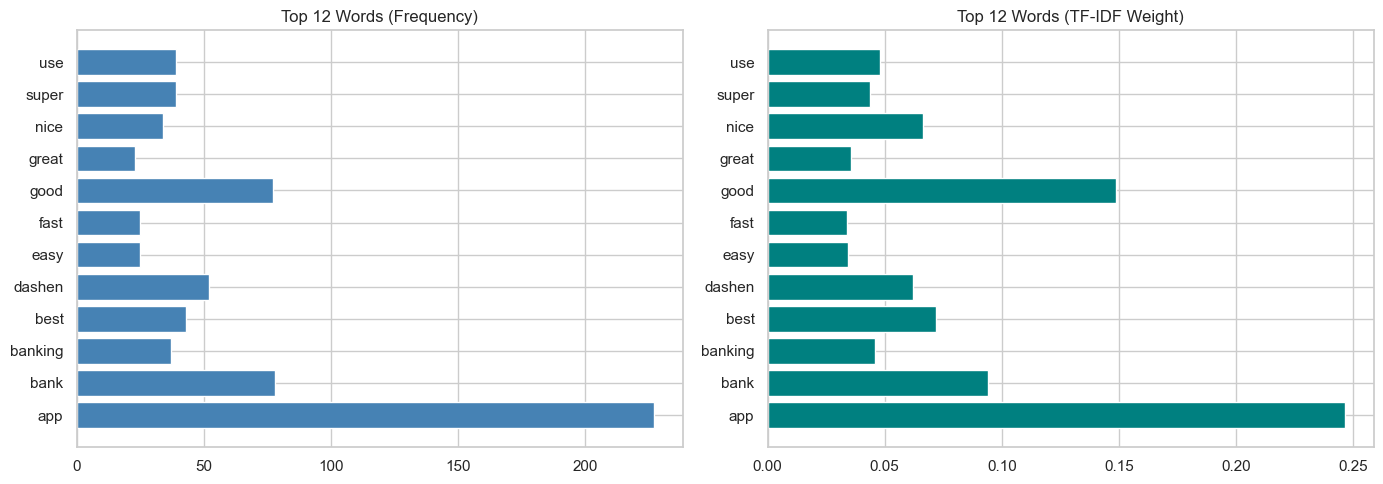

In [26]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## N-gram Analysis


C:\Users\dagic\AppData\Local\Temp\ipykernel_15452\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_15452\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


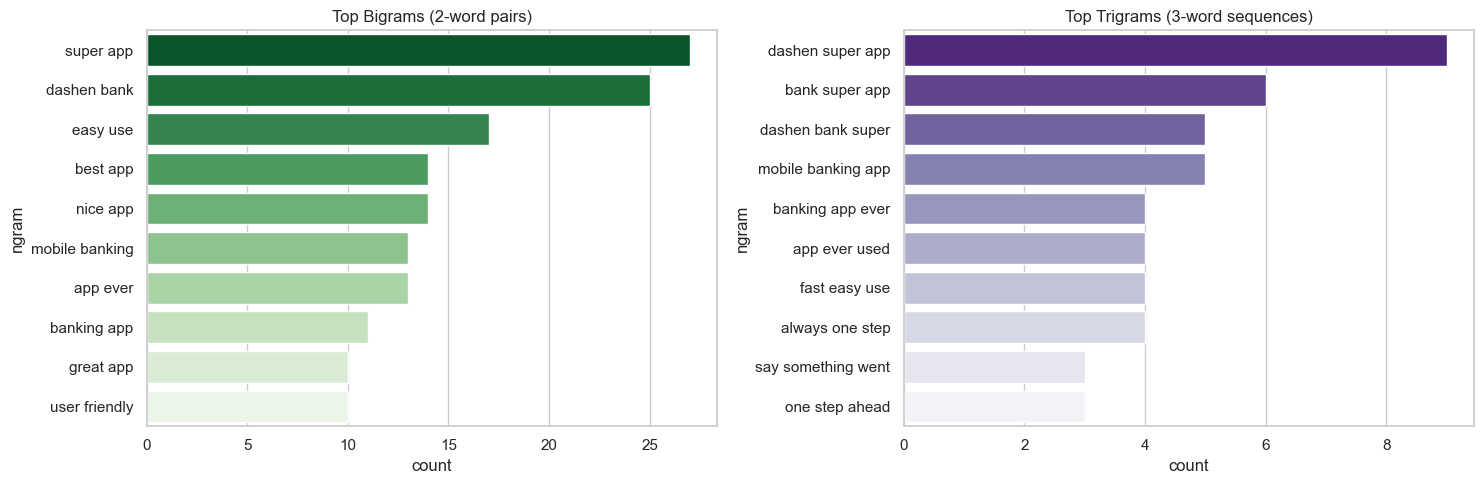

In [27]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging and Noun Extraction

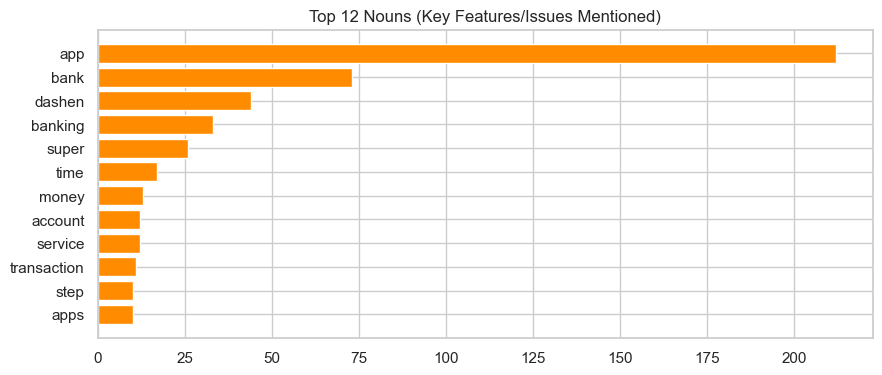

In [28]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

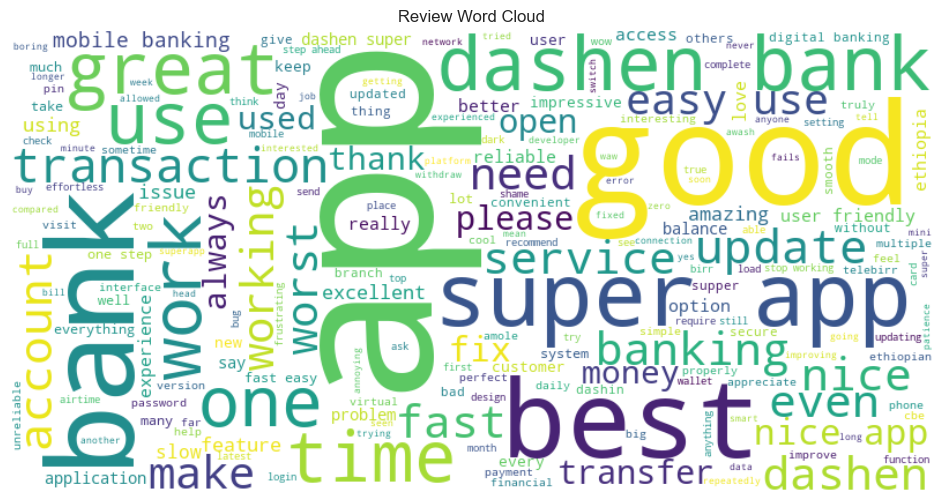

In [29]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Multi-Model Sentiment Analysis

In [30]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.67
neutral     0.19
negative    0.14
Name: proportion, dtype: float64


#### Interpretation
    The Vader distrubition showed that:
        - 67% of the total review are positive
        - 19% is neutral
        - 14% is negative
    ** this 14% of negative reviews should be analysed carefully, as it might be a bottleneck for the operational service delivery for the fintech companies.